#### 2.6 Cek Duplikasi Data

Konteks : Cell ini digunakan untuk mendeteksi apakah terdapat baris data yang kembar atau terduplikat di dalam dataset guna menjaga keaslian dan objektivitas data sebelum dilakukan pemodelan.

- `df.duplicated().sum()` : Berfungsi untuk mengecek setiap baris di dalam tabel, lalu menjumlahkan total baris data yang isinya sama persis dengan baris data lainnya.

In [7]:
print("Pengecekan Data Duplikat")
print(df.duplicated().sum())

Pengecekan Data Duplikat
0


Konteks : Cell ini berfungsi untuk membuat grafik histogram dari seluruh kolom numerik di dataset secara sekaligus guna melihat bentuk persebaran data dan mendeteksi adanya keanehan (skewness atau pencilan).

#### 2.7 Korelasi Fitur

Konteks : Cell ini digunakan untuk menghitung nilai korelasi antara setiap kolom fitur dengan kelas target stress_level

- `df.corr()` : Berfungsi untuk menghitung matriks korelasi antar semua kolom numerik untuk melihat seberapa kuat hubungan linear antar variabel.

- `['stress_level']` : Berfungsi untuk menyaring dan mengambil data korelasi yang berfokus pada kolom tingkat stres saja.

- `sort_values(ascending=False)` : Berfungsi untuk mengurutkan nilai korelasi dari yang terbesar (paling positif kuat) hingga yang terkecil (negatif kuat).

- `print(korelasi)` : Berfungsi untuk memunculkan hasil urutan korelasi tersebut ke layar komputer.

In [8]:
korelasi = df.corr()['stress_level'].sort_values(ascending=False)

print("Korelasi Fitur Terhadap Stress Level")
print(korelasi)

Korelasi Fitur Terhadap Stress Level
stress_level                    1.000000
bullying                        0.751162
future_career_concerns          0.742619
anxiety_level                   0.736795
depression                      0.734379
headache                        0.713484
extracurricular_activities      0.692977
peer_pressure                   0.690684
noise_level                     0.663371
mental_health_history           0.648644
study_load                      0.634156
breathing_problem               0.573984
blood_pressure                  0.394200
living_conditions              -0.581723
social_support                 -0.632497
teacher_student_relationship   -0.680163
basic_needs                    -0.708968
safety                         -0.709602
academic_performance           -0.720922
sleep_quality                  -0.749068
self_esteem                    -0.756195
Name: stress_level, dtype: float64


#### 2.8 Analisis Fitur Paling Berpengaruh pada Tingkat Stres

- `Fitur Paling Berpengaruh Positif`: Fitur bullying (Perundungan) mencatatkan korelasi positif terbesar yaitu 0.751162, disusul oleh future_career_concerns (0.742619), anxiety_level (0.736795), dan depression (0.734379).

    - Insight: Tekanan sosial luar akibat perundungan dan kekhawatiran masa depan bertindak sebagai faktor eksternal utama yang paling cepat memicu lonjakan stres mahasiswa secara signifikan.

- `Fitur Paling Berpengaruh Negatif`: Fitur self_esteem (Harga Diri) menempati korelasi negatif terbesar secara mutlak yaitu -0.756195, diikuti oleh sleep_quality (-0.749068) dan academic_performance (-0.720922).
    - Insight: Hubungan berbanding terbalik ini membuktikan bahwa harga diri yang tinggi dan kualitas istirahat/tidur yang prima bertindak sebagai sistem pertahanan internal terkuat yang mampu menekan tingkat stres mahasiswa ke titik terendah.
    
- `Kesimpulan Analisis`: Stres mahasiswa dalam dataset ini dikendalikan oleh interaksi erat dua kutub utama: Tekanan Sosial Luar (bullying & future_career_concerns) sebagai daya dorong stres terbesar, dan Kekuatan Resiliensi Internal (self_esteem & sleep_quality) sebagai penahan stres terkuat.

#### 2.9 Heatmap Korelasi Fitur

`Konteks` : Cell ini berfungsi untuk menampilkan visualisasi peta panas (heatmap) dari matriks korelasi seluruh variabel guna mempermudah analisis hubungan antar-fitur secara visual melalui gradasi warna

`plt.figure(figsize=(15, 12))` : Berfungsi untuk membuat bingkai kanvas grafik baru dengan ukuran lebar 15 inci dan tinggi 12 inci agar kotak-kotak matriks tidak terlalu padat.

`sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)` : Berfungsi untuk menggambar grafik peta panas dari tabel korelasi, menampilkan angka koefisien di tiap kotak (annot=True), menggunakan skema warna biru-merah (cmap='coolwarm'), membatasi dua angka di belakang koma (fmt='.2f'), dan memberi jarak antar-kotak sebesar 0.5 piksel (linewidths=0.5).

`plt.title("Matriks Korelasi Pearson - Dataset Tingkat Stres", fontsize=14, fontweight='bold')` : Berfungsi untuk menambahkan judul di atas grafik dengan ukuran huruf 14 dan format tulisan tebal.

`plt.show()` : Berfungsi untuk memunculkan gambar peta panas korelasi yang telah dikonfigurasi ke layar komputer.

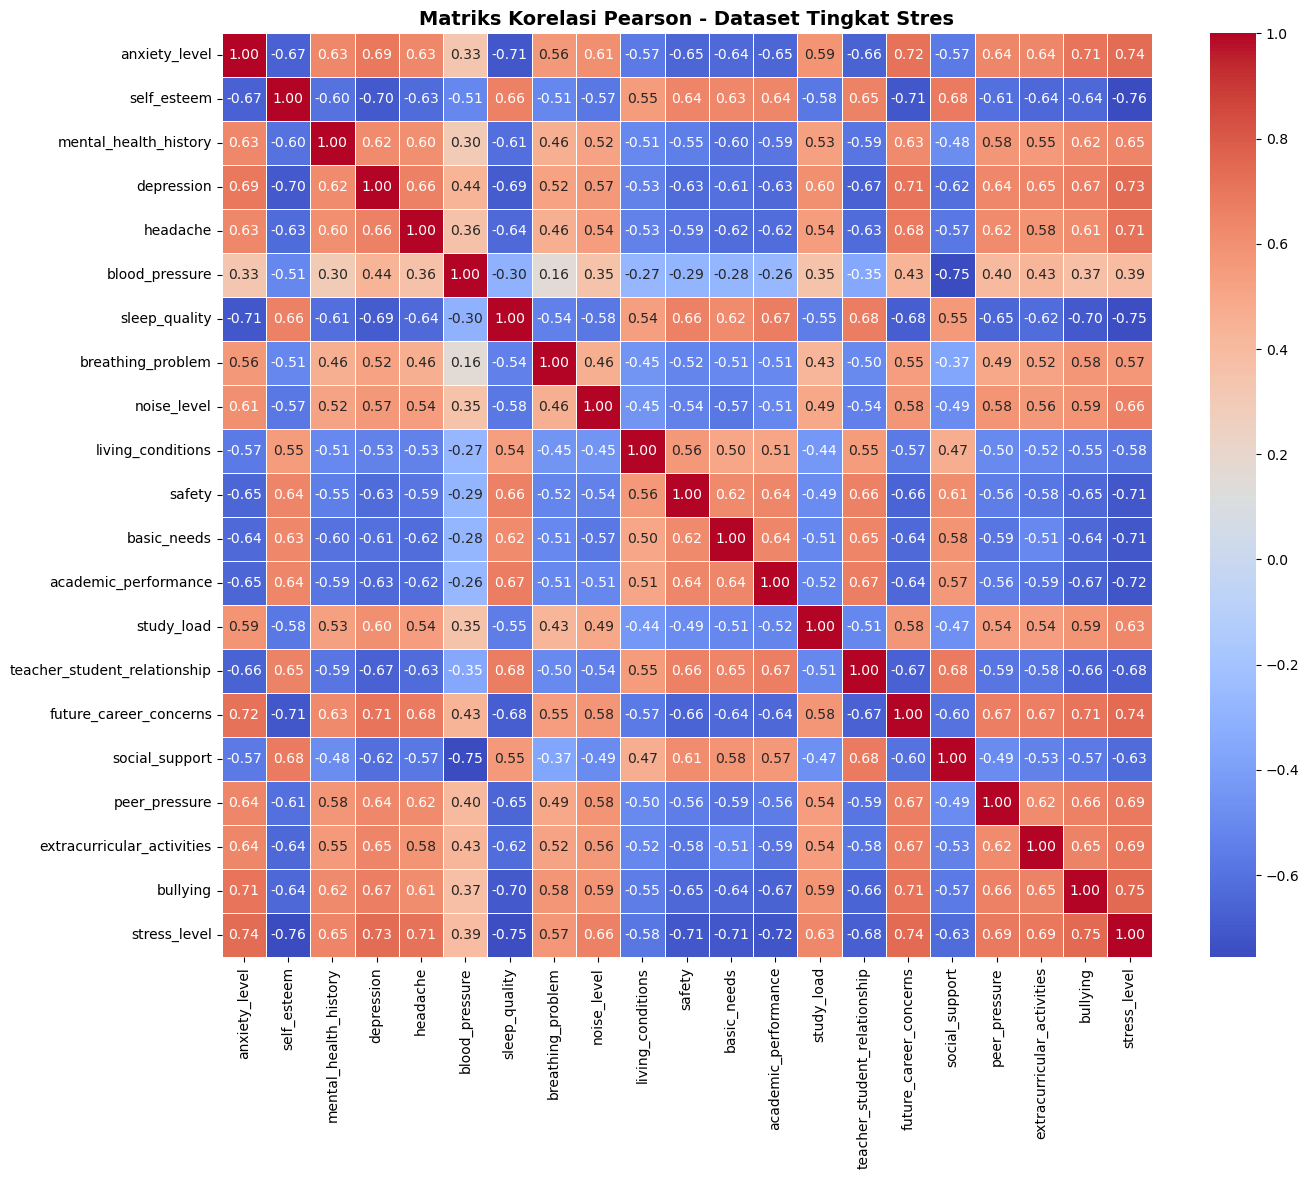

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Matriks Korelasi Pearson - Dataset Tingkat Stres", fontsize=14, fontweight='bold')
plt.show()

#### 2.10 Interpretasi Hubungan Antar-Variabel (Analisis Heatmap)
Berdasarkan visualisasi matriks korelasi (Heatmap), terdapat hubungan sebab-akibat (korelasi diagonal) yang kuat antar-variabel independen di luar variabel target:

- `Hubungan Simbiotis Psikologis (anxiety_level dan depression)`: Jika kita lihat titik temu (irisan) antara baris kecemasan dan kolom depresi, angkanya cukup tinggi yaitu 0.69. Artinya, kedua masalah mental ini hampir selalu berjalan beriringan. Mahasiswa yang tingkat kecemasannya tinggi, kemungkinan besar juga merasakan gejala depresi di waktu yang sama. Hubungan erat ini sejalan dengan pengaruh kuat keduanya langsung ke tingkat stres, di mana kecemasan punya nilai 0.74 dan depresi 0.73 ke arah

- `Hubungan Fisiologis-Akademis (sleep_quality dan study_load)`:Irisan antara kualitas tidur dan beban belajar menunjukkan angka minus, yaitu -0.55. Tanda minus ini artinya berbanding terbalik. Semakin padat tugas dan jadwal kuliah mahasiswa (study_load tinggi), maka waktu istirahat mereka akan langsung dikorbankan sehingga kualitas tidur (sleep_quality) otomatis langsung merosot drastis.

  
- `Hubungan Sakit Kepala dengan Lingkungan (headache dan noise_level / breathing_problem)` :
Irisan sakit kepala (headache) dengan kebisingan (noise_level) nilainya 0.54, dan dengan gangguan pernapasan (breathing_problem) nilainya 0.46. Ini artinya kalau lingkungan sekitar berisik dan udaranya tidak sehat, otomatis bikin mahasiswa jadi makin gampang sakit kepala.

#### 2.11 Processing

`Konteks` : Cell ini berfungsi untuk mengeliminasi kolom-kolom tertentu yang dinilai kurang relevan dari dataset, lalu menampilkan daftar kolom terbaru beserta jumlah total fiturnya setelah pembersihan.

In [10]:
kolom_dibuang = ['blood_pressure', 'breathing_problem', 'living_conditions']
df_clean = df.drop(columns=kolom_dibuang)

print("Pengecekan Kolom Terbaru")
print(df_clean.columns.tolist())
print(f"\nJumlah fitur sekarang: {df_clean.shape[1]} kolom")

Pengecekan Kolom Terbaru
['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'sleep_quality', 'noise_level', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']

Jumlah fitur sekarang: 18 kolom


#### 2.12 Justifikasi Statistik Penghapusan Fitur Berdasarkan Ambang Batas Korelasi

Penghapusan fitur blood_pressure, breathing_problem, dan living_conditions dilakukan secara objektif menggunakan metode seleksi fitur berbasis filter (Filter-based Feature Selection), dengan justifikasi sebagai berikut:

- `Penerapan Batas Threshold`: >= 0,6 Untuk membangun model yang efisien, penelitian ini menetapkan standar bahwa hanya fitur dengan hubungan linear kuat yang dipertahankan, yaitu yang memiliki nilai koefisien korelasi Pearson terhadap stress_level di atas $0.6$ atau di bawah $-0.6$.

- `Hasil Pengujian Nilai Korelasi`: Berdasarkan matriks korelasi yang telah dihitung sebelumnya, fitur blood_pressure, breathing_problem, dan living_conditions memiliki nilai korelasi yang lemah (berada di dalam rentang $-0.6$ hingga $0.6$) terhadap variabel target stress_level.

- `Tujuan Eliminasi`: Penghapusan fitur dengan korelasi lemah dilakukan secara sengaja untuk membersihkan data dari informasi yang tidak relevan (noise). Secara statistik, jika fitur yang tidak berpengaruh tetap dimasukkan, model akan dipaksa mempelajari pola yang salah. Langkah ini sangat krusial untuk mencegah model mengalami overfitting (menghafal data latihan) serta menyederhanakan arsitektur data agar proses komputasi Grid Search berjalan jauh lebih cepat dan menghasilkan prediksi yang lebih stabil.

#### 2.13 Analisis Seleksi Fitur (Feature Selection Analysis)

Proses seleksi fitur dalam penelitian ini menggunakan pendekatan Filter Method dengan memanfaatkan koefisien korelasi Pearson. Berikut adalah analisis menyeluruh mengapa fitur tertentu dipertahankan atau dibuang dari arsitektur model:

- `Kriteria Penyaringan (Filter)`: Fitur dinyatakan lolos dan dipertahankan jika memiliki nilai kekuatan korelasi $|r| \ge 0.6$ terhadap tingkat stres. Fitur yang tidak memenuhi ambang batas tersebut otomatis dibuang karena dianggap sebagai noise yang dapat mengaburkan pola klasifikasi algoritma.

- `Fitur yang Dipertahankan`: Fitur seperti anxiety_level, depression, sleep_quality, safety, dan academic_performance secara konsisten memiliki nilai korelasi di atas batas kritis $0.6$ (atau di bawah $-0.6$). Fitur-fitur ini dipertahankan karena secara statistik membawa informasi krusial yang memiliki sensitivitas tinggi terhadap perubahan tingkat stres mahasiswa.

- `Secara Teori Statistik (Standar Guilford / Devore)`: Dalam ilmu statistika, nilai korelasi Pearson di atas 0,6 itu sudah masuk dalam kategori Korelasi Kuat hingga Sangat Kuat (rentang 0,6 sampai 1,0). Jadi, angka 0,6 dipilih sebagai batas aman (filter baseline) untuk memastikan bahwa fitur yang kita pertahankan beralasan kuat dan punya hubungan linear yang nyata dengan tingkat stres mahasiswa.

    - Menjaga Keseimbangan Data (Sweet Spot): Angka 0,6 adalah titik tengah yang paling adil.

    - Kalau kita pakai batas terlalu rendah (misal 0,4), fitur seperti tekanan darah bakal ikut masuk, padahal itu cuma noise (sampah informasi) yang bikin model bingung.

    - Kalau kita pakai batas terlalu tinggi (misal 0,75), kita cuma bakal punya 1 atau 2 fitur saja, sehingga model kekurangan informasi buat belajar (underfitting).

Jadi, angka 0,6 dipilih karena berhasil menyaring fitur-fitur terbaik yang informatif (seperti bullying, anxiety, depression, dan sleep quality) dan otomatis mendepak fitur yang tidak relevan.

#### 2.14 Transformasi Data

`Konteks` : Cell ini berfungsi untuk memisahkan dataset menjadi variabel independen X (seluruh fitur input) dan variabel dependen y (kelas target stress_level), serta memastikan dimensi ukurannya sebelum masuk ke tahap modelling.

`X = df_clean.drop(columns=['stress_level'])` : Berfungsi untuk membuat variabel X yang berisi semua kolom fitur setelah menghapus kolom target stress_level.

`y = df_clean['stress_level']` : Berfungsi untuk membuat variabel y yang hanya mengisolasi atau mengambil satu kolom target stress_level sebagai label prediksi.

`print("Dimensi X (Semua Fitur):", X.shape)` : Berfungsi untuk memunculkan ukuran matriks X (jumlah baris dan kolom fitur) ke layar guna memastikan tidak ada fitur target yang ikut terbawa.

`print("Dimensi y (Semua Target):", y.shape)` : Berfungsi untuk memunculkan ukuran vektor y (jumlah baris target) ke layar komputer guna memastikan ukurannya sinkron dengan variabel X.

In [11]:
X = df_clean.drop(columns=['stress_level'])
y = df_clean['stress_level']

print("Verifikasi data")
print("Dimensi X (Semua Fitur):", X.shape)
print("Dimensi y (Semua Target):", y.shape)

Verifikasi data
Dimensi X (Semua Fitur): (1100, 17)
Dimensi y (Semua Target): (1100,)


#### 2.15 Scalling Data

`Konteks` : Cell ini berfungsi untuk menyelaraskan skala seluruh nilai fitur pada variabel X menggunakan metode standardisasi (Z-score) agar semua kolom memiliki rata-rata nol dan standar deviasi satu, sehingga performa model algoritma menjadi lebih optimal dan adil.

`from sklearn.preprocessing import StandardScaler` : Berfungsi untuk memanggil modul StandardScaler dari library Scikit-Learn yang digunakan untuk melakukan standardisasi data.

`scaler = StandardScaler()` : Berfungsi untuk menginisialisasi atau membuat objek penskalaan baru dengan nama variabel scaler.

`X_scaled = scaler.fit_transform(X)` : Berfungsi untuk menghitung nilai rata-rata serta standar deviasi dari data X (fit), lalu langsung mengubah seluruh nilai fiturnya ke dalam skala baru yang seimbang (transform).

`print(X_scaled[:5])` : Berfungsi untuk menampilkan data matriks X yang telah berhasil di-scale, khusus untuk 5 baris pertama saja sebagai sampel verifikasi.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data setelah scaling (5 baris pertama):")
print(X_scaled[:5])

Data setelah scaling (5 baris pertama):
[[ 0.48020782  0.24861241 -0.98555881 -0.20139257 -0.36074135 -0.42644513
  -0.48894889  0.18692374 -0.53919641  0.16073598 -0.47279981  0.25421325
   0.22955038  0.11283889  0.18633396  0.16424895 -0.40337716]
 [ 0.64374608 -1.09358954  1.0146528   0.31650766  1.76885873 -1.0725741
   0.26433372 -0.5245507  -0.53919641 -1.25374063  1.04790134 -1.19092669
   1.53786859 -0.84195172  0.88827696  1.57576339  1.5570715 ]
 [ 0.15313129  0.02491208  1.0146528   0.18703261 -0.36074135 -0.42644513
  -0.48894889  0.18692374 -0.53919641 -0.54650233  0.28755076  0.25421325
  -0.42460873  0.11283889  0.18633396 -0.54150826 -0.40337716]
 [ 0.80728435 -0.64618889  1.0146528   0.31650766  1.05899204 -1.0725741
   1.01761632 -0.5245507  -0.53919641 -0.54650233  1.04790134 -1.19092669
   0.88370948 -0.84195172  0.88827696  0.87000617  1.5570715 ]
 [ 0.80728435  1.1434137  -0.98555881 -0.7192928  -0.36074135  1.51194181
   0.26433372  0.89839818  0.15858718  0.867

#### 2.16 Justifikasi Penggunaan StandardScaler Terhadap Karakteristik Algoritma
Penerapan StandardScaler (mengubah skala data sehingga memiliki rata-rata 0 dan varians 1) sangat krusial dalam penelitian ini karena karakteristik dari tiga algoritma yang digunakan memiliki sensitivitas yang berbeda terhadap skala data:

- `Keterkaitan dengan K-Nearest Neighbors (KNN)`: KNN adalah algoritma berbasis jarak geometris (seperti Euclidean distance). Jika data tidak distandardisasi, fitur dengan rentang nilai yang besar (misalnya fitur psikologis dengan skala hingga puluhan) akan mendominasi perhitungan jarak, sehingga fitur berskala kecil (skala ordinal 0-5) akan diabaikan oleh model. StandardScaler memastikan seluruh fitur berkontribusi secara adil dalam penentuan tetangga terdekat.

- `Keterkaitan dengan Naïve Bayes`: Pada varian Gaussian Naïve Bayes, algoritma ini mengasumsikan bahwa fitur-fitur numerik terdistribusi secara normal. Melakukan standardisasi membantu mengubah data ke dalam bentuk distribusi yang memiliki skala seragam, sehingga perhitungan probabilitas bersyarat (conditional probability) berbasis fungsi kepadatan menjadi lebih stabil.

- `Keterkaitan dengan Decision Tree`: Secara teori, Decision Tree bersifat konsisten terhadap skala fitur karena pembagian node (splitting) dihitung secara terpisah per fitur berdasarkan Information Gain atau Gini Impurity. Namun, standardisasi data di awal tetap dipertahankan agar seluruh data input berada pada format yang konsisten, memudahkan perbandingan performa antar-model, dan memastikan konsistensi alur kerja pra-pemrosesan data.

## 3.  Imbalanced Data

#### 3.1 Pengecekan Keseimbangan Data

`Konteks` : Cell ini digunakan untuk menghitung jumlah sebaran data dan persentase di setiap kategori pada variabel target y guna memastikan kembali bahwa proporsi kelas tidak berubah dan tetap seimbang sebelum masuk ke tahap pelatihan model.

- `print(y.value_counts())`` ` : Berfungsi untuk menghitung dan menampilkan total jumlah baris data yang ada pada masing-masing tingkatan kelas target di dalam variabel y.

- `print(y.value_counts(normalize=True) * 100)`` ` : Berfungsi untuk mengubah hitungan jumlah baris data tadi ke dalam format persentase (%) agar lebih mudah dianalisis keseimbangan datanya.

In [13]:
print("Jumlah Data")
print(y.value_counts())

print("\nPersentase Data")
print(y.value_counts(normalize=True) * 100)

Jumlah Data
stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Persentase Data
stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


#### 3.2 Pembahasan Klasifikasi Status Keseimbangan Dataset

Berdasarkan hasil kalkulasi nilai unik pada variabel target stress_level menggunakan fungsi .value_counts(), diperoleh analisis formal mengenai status distribusi data sebagai berikut:

- `Analisis Proporsi Sampel`: Dataset memiliki total 1100 baris data, di mana sebaran sampel untuk Kelas 0 (Rendah), Kelas 1 (Sedang), dan Kelas 2 (Tinggi) terbagi secara merata tanpa ada perbedaan jumlah nominal yang mencolok.

- `Kesimpulan Status Data`: Dengan kondisi sebaran yang merata, secara teori dan statistik dataset ini termasuk ke dalam kelompok Dataset Seimbang Sempurna (Perfectly Balanced Dataset). Kondisi ideal seperti ini sangat menguntungkan karena menghilangkan bias algoritma terhadap salah satu kelas mayoritas tertentu.

#### 3.3 Justifikasi Penanganan Imbalance Data (Mengapa Tidak Menggunakan SMOTE)

Sebagai konsekuensi dari status dataset yang sudah seimbang sempurna pada tahap pengecekan, maka langkah penanganan imbalance data diputuskan dengan justifikasi ilmiah sebagai berikut:

- `Peniadaan Algoritma Resampling`: Eksperimen ini secara sengaja tidak menerapkan teknik manipulasi data sintetis seperti SMOTE (Synthetic Minority Over-sampling Technique) ataupun metode Under-sampling.

- `Justifikasi Statistik`: Memaksakan penggunaan algoritma SMOTE pada data yang sudah seimbang secara alami adalah sebuah kesalahan fatal dalam praktik data sains. Hal tersebut berpotensi besar memicu masalah overfitting yang parah akibat terjadinya duplikasi informasi dan pembuatan titik data tiruan baru yang sebenarnya tidak dibutuhkan oleh model.